In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.seasonal import seasonal_decompose
import scipy.signal as signal


In [ ]:
df = pd.read_excel("Datos Capricornio 1.xlsx")

In [ ]:
# 3. Convertir columna 'Time' a datetime con fecha arbitraria (para graficar)
df["Datetime"] = pd.to_datetime("2025-01-01 " + df["Time"].astype(str))

In [ ]:
df.head()


,Time,BME280 Temp (ºC),BME280 Temp (ºF),BME280 Humidity (%),BME280 Pressure (hPa),Altitud (m),TSL2561 Full (lux),TSL2561 IR (lux),TSL2561 Visible (lux),MPU Accel_x (g),...,Gyro_x (°/s),Gyro_y (°/s),Gyro_z (°/s),MQ Voltage (V),MQ Rs (Ω),MQ Ratio,MQ Concentration (ppm),Unnamed: 19,Unnamed: 20,Datetime
0,06:00:00,29.71,85.48,70.14,980.44,276.818309,3176.738445,1471.399751,1705.338694,0.00,...,-1.20,-1.89,-0.97,0.795,105845.52,29.40,0.7309,NaN,NaN,2025-01-01 06:00:00
1,06:00:03,29.69,85.44,70.09,980.46,276.647299,3480.995394,1649.505560,1831.489834,-0.01,...,-1.11,-0.06,-1.11,0.794,105904.94,29.42,0.7297,NaN,NaN,2025-01-01 06:00:03
2,06:00:05,29.66,85.38,70.00,980.47,276.561795,3659.592637,1674.892235,1984.700402,0.00,...,-1.52,-0.18,-0.94,0.794,105924.76,29.42,0.7293,NaN,NaN,2025-01-01 06:00:05
3,06:00:08,29.65,85.38,69.99,980.46,276.647299,2991.244014,1392.863956,1598.380058,-0.01,...,-0.98,-0.01,-1.22,0.794,105885.13,29.41,0.7301,NaN,NaN,2025-01-01 06:00:08
4,06:00:10,29.72,85.50,70.15,980.46,276.647299,2867.902797,1197.246252,1670.656545,0.00,...,-2.12,-0.82,-0.94,0.794,105885.13,29.41,0.7301,NaN,NaN,2025-01-01 06:00:10


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3768 entries, 0 to 3767
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Time                    3768 non-null   object        
 1   BME280 Temp (ºC)        3768 non-null   float64       
 2   BME280 Temp (ºF)        3768 non-null   float64       
 3   BME280 Humidity (%)     3768 non-null   float64       
 4   BME280 Pressure (hPa)   3768 non-null   float64       
 5   Altitud (m)             3768 non-null   float64       
 6   TSL2561 Full (lux)      3768 non-null   float64       
 7   TSL2561 IR (lux)        3768 non-null   float64       
 8   TSL2561 Visible (lux)   3768 non-null   float64       
 9   MPU Accel_x (g)         3768 non-null   float64       
 10  Accel_y (g)             3768 non-null   float64       
 11  Accel_z (g)             3768 non-null   float64       
 12  Gyro_x (°/s)            3768 non-null   float64 

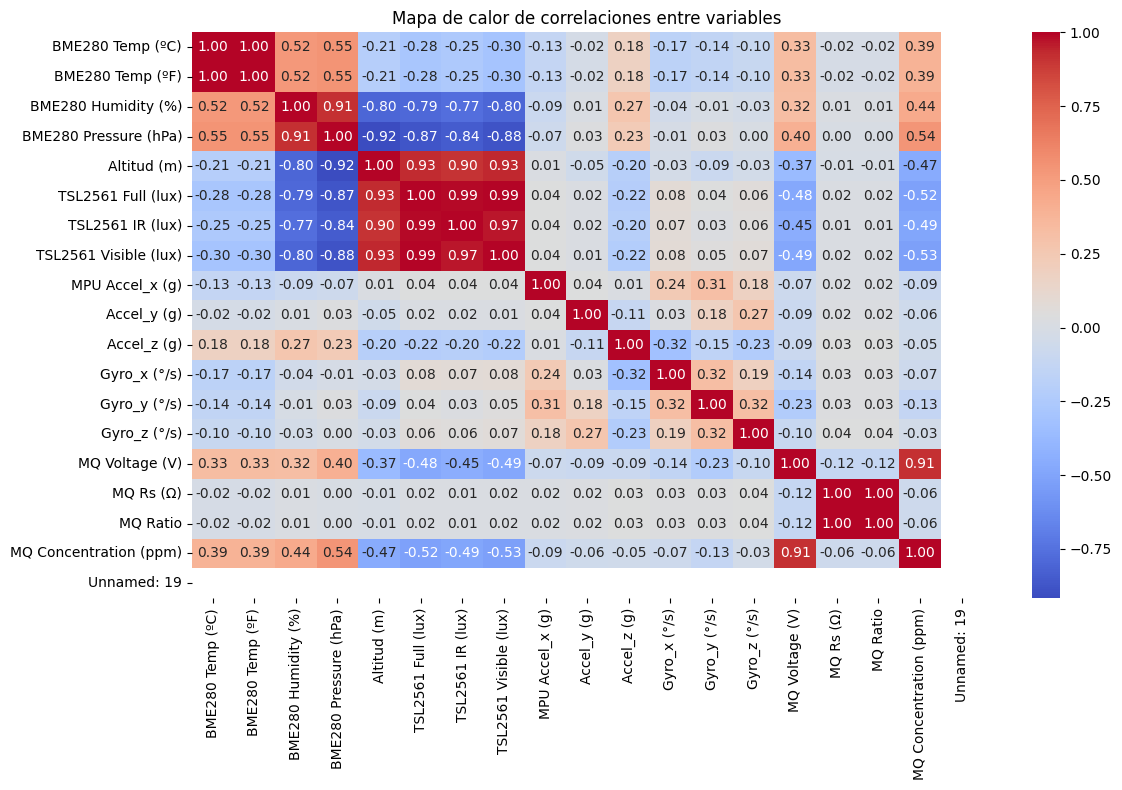

In [ ]:
# 8. Mapa de calor de correlaciones
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Mapa de calor de correlaciones entre variables")
plt.tight_layout()
plt.show()

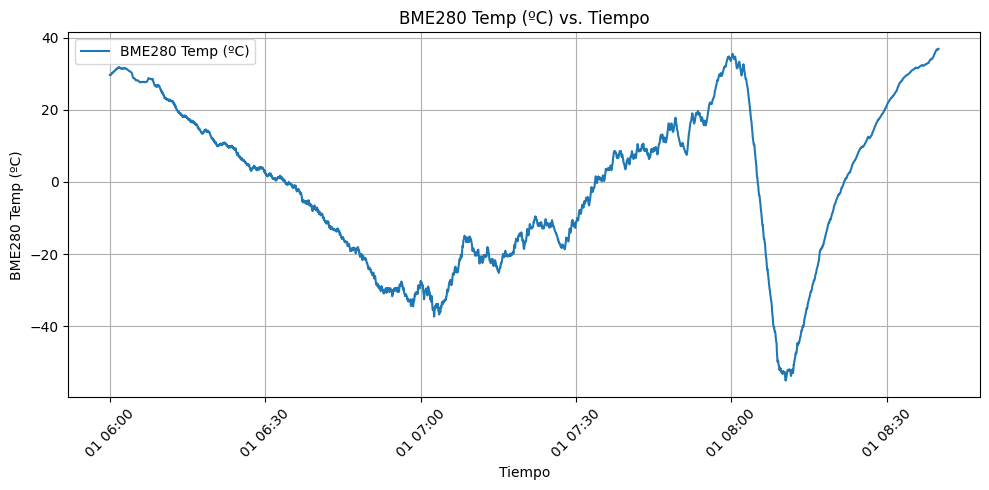

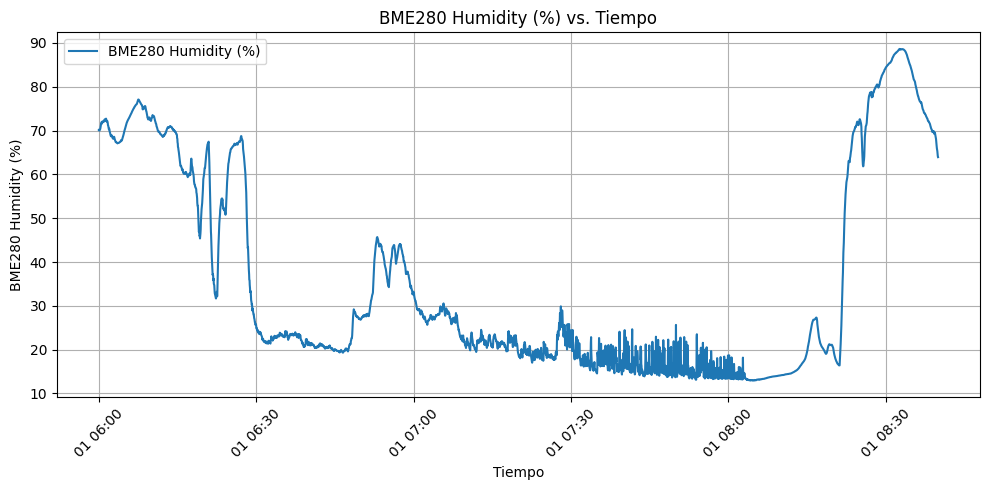

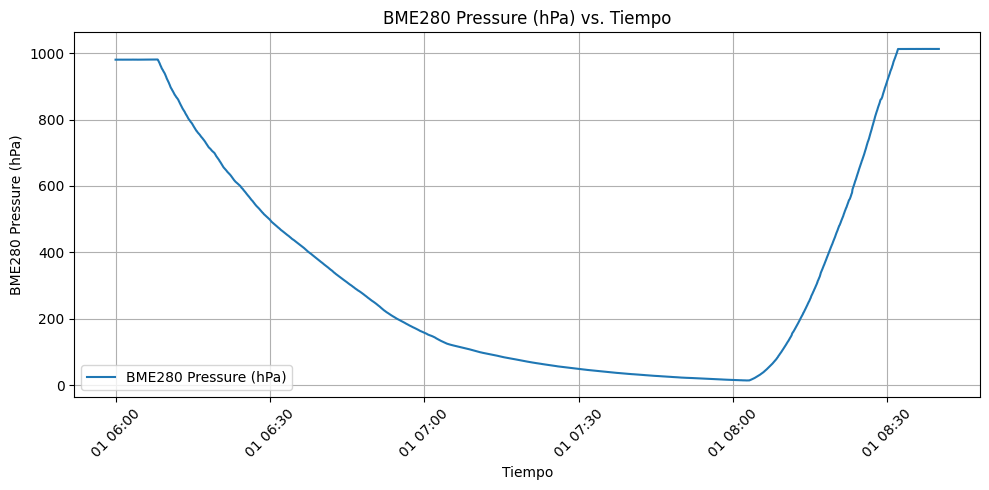

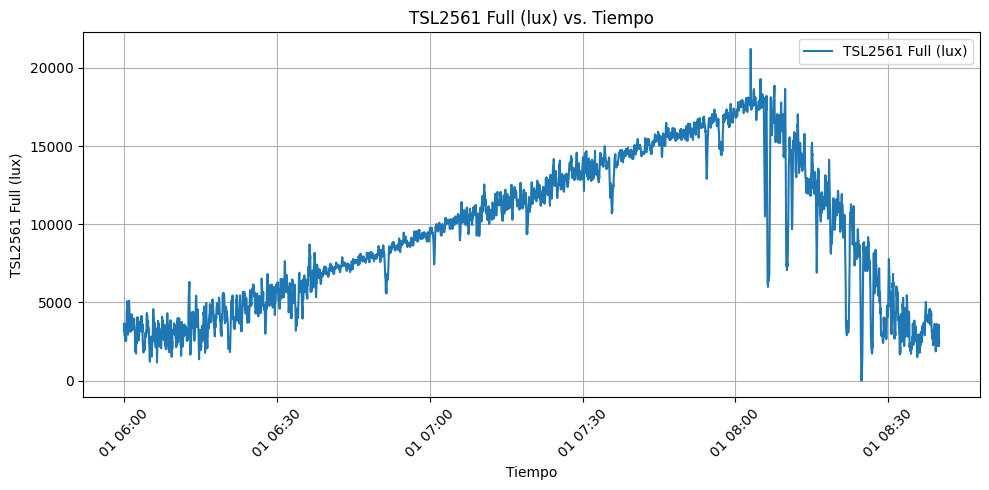

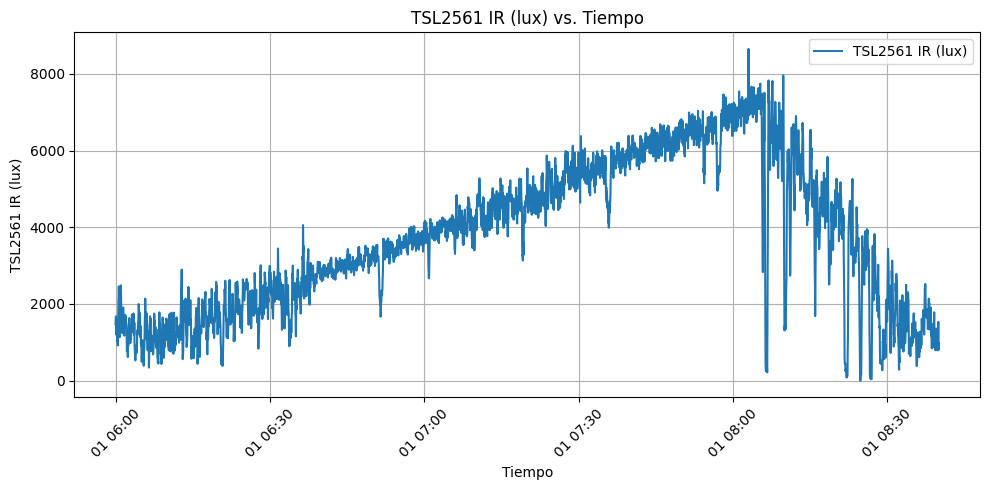

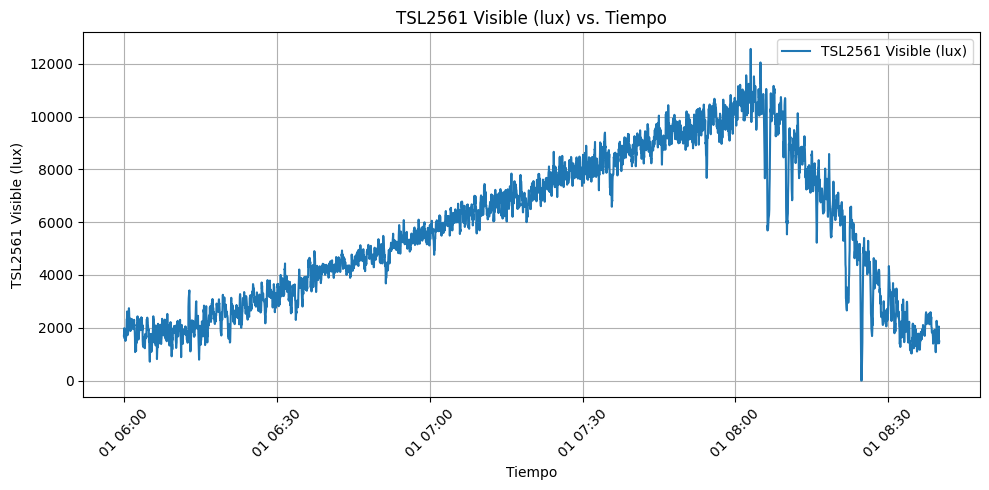

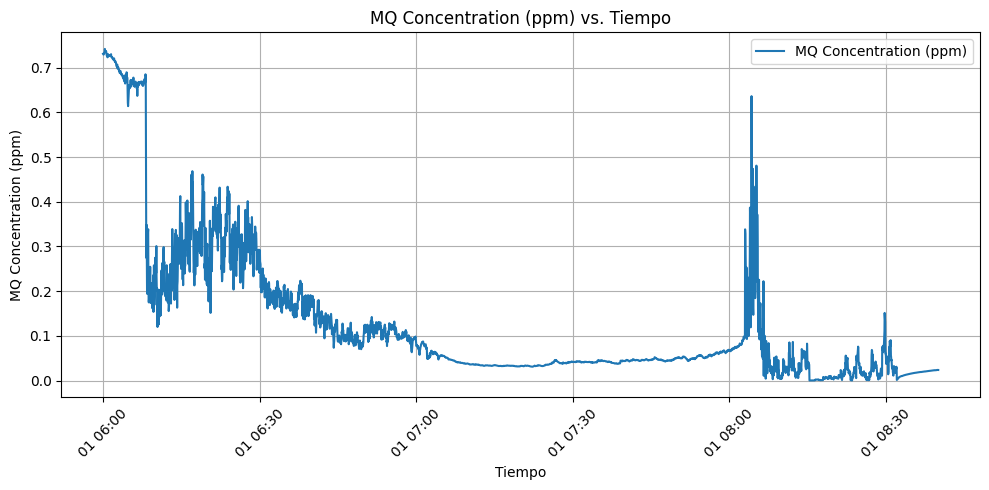

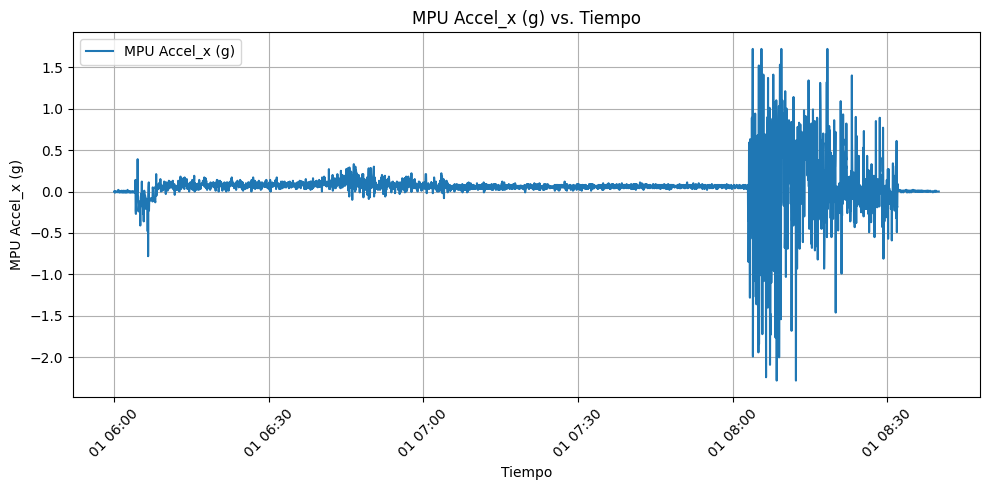

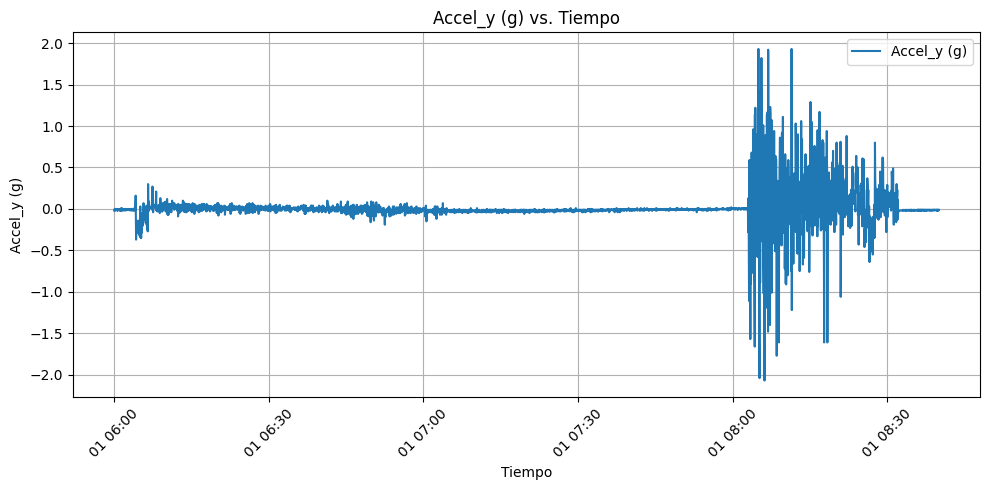

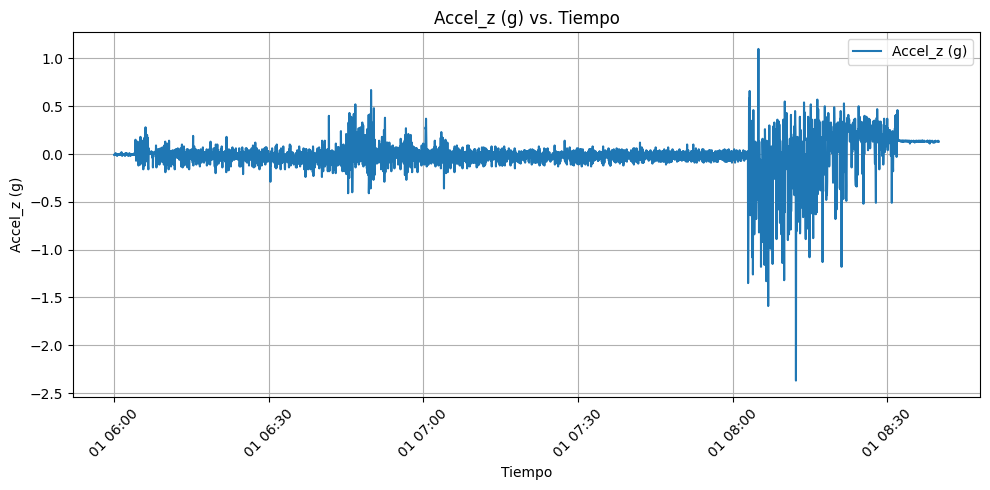

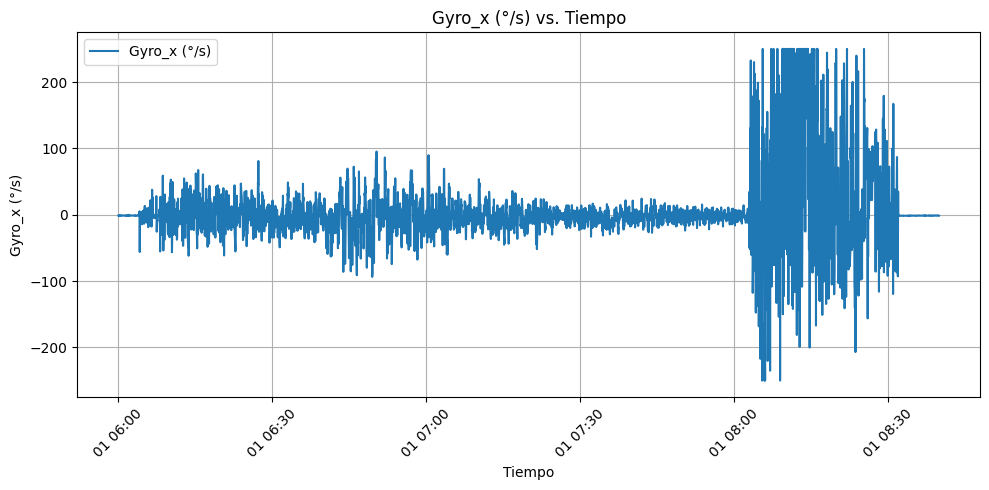

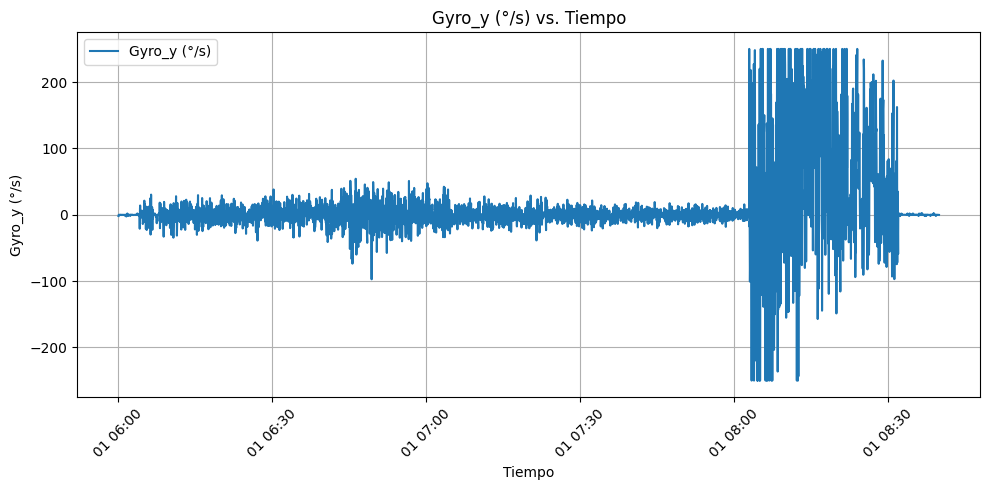

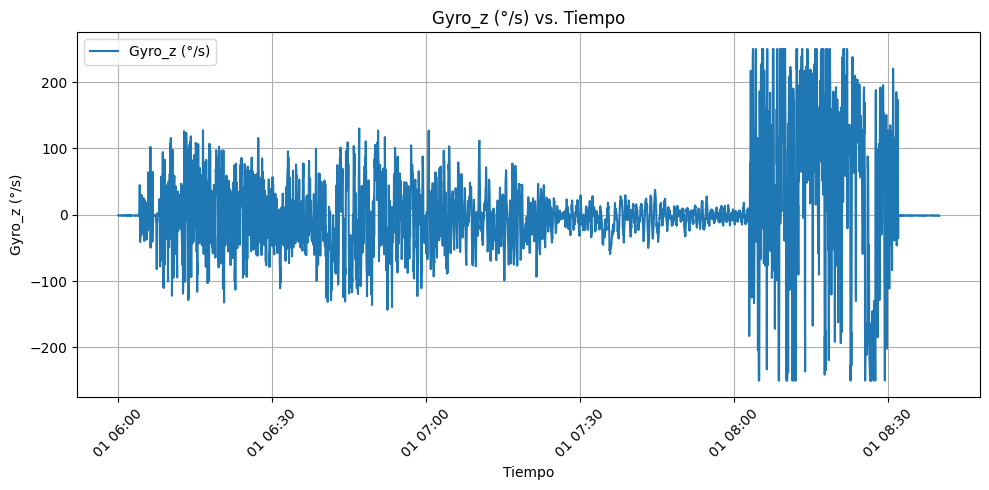

In [ ]:
# Paso 4: Lista de variables numéricas a graficar vs tiempo
variables = [
    "BME280 Temp (ºC)",
    "BME280 Humidity (%)",
    "BME280 Pressure (hPa)",
    "TSL2561 Full (lux)",
    "TSL2561 IR (lux)",
    "TSL2561 Visible (lux)",
    "MQ Concentration (ppm)",
    "MPU Accel_x (g)",
    "Accel_y (g)",
    "Accel_z (g)",
    "Gyro_x (°/s)",
    "Gyro_y (°/s)",
    "Gyro_z (°/s)"
]

# Paso 5: Graficar cada variable contra el tiempo
for var in variables:
    if var in df.columns:
        plt.figure(figsize=(10, 5))
        plt.plot(df["Datetime"], df[var], label=var)
        plt.title(f"{var} vs. Tiempo")
        plt.xlabel("Tiempo")
        plt.ylabel(var)
        plt.grid(True)
        plt.legend()
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()